# Aula de Machine Learning — Classificação com Boas Práticas

---

## Roteiro

| Etapa | Descricao |
|---|---|
| 1 | Instalacao e Importacoes |
| 2 | Carregamento do Dataset |
| 3 | Analise Exploratoria de Dados (EDA) |
| 4 | Preparacao dos Dados |
| 5 | Tuning de Hiperparametros com Optuna + Validacao Cruzada |
| 6 | Selecao do Melhor Modelo |
| 7 | Treinamento Final e Avaliacao no Teste |
| 8 | Visualizacoes de Avaliacao |

---

### Modelos Candidatos
- XGBoost
- LightGBM
- Random Forest
- Arvore de Decisao
- Regressao Logistica

### Dataset: UCI Heart Disease

**Problema:** Classificar se um paciente tem doenca cardiaca com base em exames clinicos.  
**Target:** `target` (1 = doenca presente, 0 = ausente)  
**Fonte:** UCI Machine Learning Repository

---

> **Regra de ouro:** O conjunto de teste e tocado uma unica vez, ao final do processo.  
> Qualquer decisao de modelagem (selecao de modelo, tuning) usa apenas treino e validacao cruzada.

## 1. Instalacao e Importacoes

In [1]:
# Instalacao das bibliotecas que nao estao no ambiente padrao do Colab.
# O flag --quiet suprime saidas verbosas de instalacao.
!pip install optuna lightgbm xgboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.4 MB/s eta 0:00:00


In [2]:
# ------------------------------------------------------------------
# Supressao de warnings nao criticos para manter o output limpo.
# ------------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')

# Bibliotecas de manipulacao de dados
import numpy as np
import pandas as pd

# Bibliotecas de visualizacao
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ------------------------------------------------------------------
# Scikit-learn: utilitarios de dados, modelos e metricas
# ------------------------------------------------------------------
from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    classification_report
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Algoritmos de boosting
import xgboost as xgb
import lightgbm as lgb

# ------------------------------------------------------------------
# Optuna: framework de otimizacao de hiperparametros por busca
# bayesiana (TPE — Tree-structured Parzen Estimator).
# ------------------------------------------------------------------
import optuna
from optuna.samplers import TPESampler

# Silencia logs do Optuna durante os trials
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ------------------------------------------------------------------
# Semente global para reprodutibilidade.
# Garante que resultados sejam identicos em execucoes futuras.
# ------------------------------------------------------------------
SEED = 42
np.random.seed(SEED)

# ------------------------------------------------------------------
# Configuracao do estilo dos graficos.
# Usamos um tema escuro com paleta de cores destacada.
# ------------------------------------------------------------------
plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d27',
    'axes.edgecolor'   : '#3a3d4d',
    'axes.labelcolor'  : '#e0e0e0',
    'text.color'       : '#e0e0e0',
    'xtick.color'      : '#b0b0b0',
    'ytick.color'      : '#b0b0b0',
    'grid.color'       : '#2a2d3a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.size'        : 12,
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
})

# Paleta principal usada em todos os graficos
PALETTE = ['#00c2ff', '#ff6b6b', '#ffd93d', '#6bcb77', '#c77dff']

print('Importacoes concluidas com sucesso.')

Importacoes concluidas com sucesso.


## 2. Carregamento do Dataset

In [3]:
# ------------------------------------------------------------------
# Dataset: Heart Disease (UCI)
#
# Descricao: 303 pacientes avaliados clinicamente para doenca
# coronariana. Inclui variaveis demograficas, sintomas e resultados
# de exames complementares.
#
# fetch_openml busca o dataset diretamente do repositorio OpenML,
# sem necessidade de download manual.
# ------------------------------------------------------------------
print('Carregando dataset Heart Disease (UCI)...')

dataset = fetch_openml(name='heart-statlog', version=1, as_frame=True)

df = dataset.frame.copy()

# A coluna target vem como string ('present'/'absent'); convertemos para binario.
df['target'] = (df['class'] == 'present').astype(int)
df.drop(columns=['class'], inplace=True)

# Garante que todas as colunas de features sejam numericas
feature_cols = [c for c in df.columns if c != 'target']
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')

print(f'Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas')
print(f'Features          : {len(feature_cols)}')
print(f'Target            : "target" (1=doenca presente, 0=ausente)')
df.head()

Carregando dataset Heart Disease (UCI)...
Dataset carregado: 270 linhas x 14 colunas
Features          : 13
Target            : "target" (1=doenca presente, 0=ausente)


,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,target
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


### Tradução das Colunas do Dataset

Para facilitar a compreensão dos dados, segue a tradução das colunas do DataFrame `df`:

In [4]:
column_translations = {
    'age': 'Idade',
    'sex': 'Sexo',
    'chest': 'Tipo de Dor no Peito (angina)',
    'resting_blood_pressure': 'Pressão Arterial em Repouso',
    'serum_cholestoral': 'Colesterol Sérico',
    'fasting_blood_sugar': 'Açúcar no Sangue em Jejum',
    'resting_electrocardiographic_results': 'Resultados do Eletrocardiograma em Repouso',
    'maximum_heart_rate_achieved': 'Frequência Cardíaca Máxima Atingida',
    'exercise_induced_angina': 'Angina Induzida por Exercício',
    'oldpeak': 'Depressão do Segmento ST induzida por Exercício em relação ao Repouso',
    'slope': 'Inclinação do Segmento ST de Pico do Exercício',
    'number_of_major_vessels': 'Número de Vasos Principais Coloridos por Fluoroscopia',
    'thal': 'Talassemia (Distúrbio Sanguíneo)',
    'target': 'Presença de Doença Cardíaca (1=sim, 0=não)'
}

# Exibindo a tradução das colunas
print('Nome Original da Coluna -> Tradução em Português')
print('-' * 60)
for col_orig, col_trad in column_translations.items():
    print(f'{col_orig:<35} -> {col_trad}')

Nome Original da Coluna -> Tradução em Português
------------------------------------------------------------
age                                 -> Idade
sex                                 -> Sexo
chest                               -> Tipo de Dor no Peito (angina)
resting_blood_pressure              -> Pressão Arterial em Repouso
serum_cholestoral                   -> Colesterol Sérico
fasting_blood_sugar                 -> Açúcar no Sangue em Jejum
resting_electrocardiographic_results -> Resultados do Eletrocardiograma em Repouso
maximum_heart_rate_achieved         -> Frequência Cardíaca Máxima Atingida
exercise_induced_angina             -> Angina Induzida por Exercício
oldpeak                             -> Depressão do Segmento ST induzida por Exercício em relação ao Repouso
slope                               -> Inclinação do Segmento ST de Pico do Exercício
number_of_major_vessels             -> Número de Vasos Principais Coloridos por Fluoroscopia
thal                        

## 3. Analise Exploratoria de Dados (EDA)

In [5]:
# ------------------------------------------------------------------
# 3.1 Visao geral do dataset
#
# Antes de qualquer modelagem e essencial entender:
#   - O tamanho e a estrutura dos dados
#   - A presenca de valores ausentes
#   - A existencia de registros duplicados
#   - Estatisticas descritivas das variaveis
# ------------------------------------------------------------------
print('=' * 60)
print('INFORMACOES GERAIS DO DATASET')
print('=' * 60)
print(f'Shape          : {df.shape}')
print(f'Memoria        : {df.memory_usage(deep=True).sum() / 1e3:.1f} KB')
print(f'Duplicatas     : {df.duplicated().sum()}')
print(f'Valores nulos  : {df.isnull().sum().sum()}')
print()

# Estatisticas descritivas: media, desvio padrao, minimo, mediana e maximo
print('Estatisticas Descritivas:')
print(df.describe().T[['mean', 'std', 'min', '50%', 'max']].round(2).to_string())

INFORMACOES GERAIS DO DATASET
Shape          : (270, 14)
Memoria        : 30.4 KB
Duplicatas     : 0
Valores nulos  : 0

Estatisticas Descritivas:
                                        mean    std    min    50%    max
age                                    54.43   9.11   29.0   55.0   77.0
sex                                     0.68   0.47    0.0    1.0    1.0
chest                                   3.17   0.95    1.0    3.0    4.0
resting_blood_pressure                131.34  17.86   94.0  130.0  200.0
serum_cholestoral                     249.66  51.69  126.0  245.0  564.0
fasting_blood_sugar                     0.15   0.36    0.0    0.0    1.0
resting_electrocardiographic_results    1.02   1.00    0.0    2.0    2.0
maximum_heart_rate_achieved           149.68  23.17   71.0  153.5  202.0
exercise_induced_angina                 0.33   0.47    0.0    0.0    1.0
oldpeak                                 1.05   1.15    0.0    0.8    6.2
slope                                   1.59   0.6

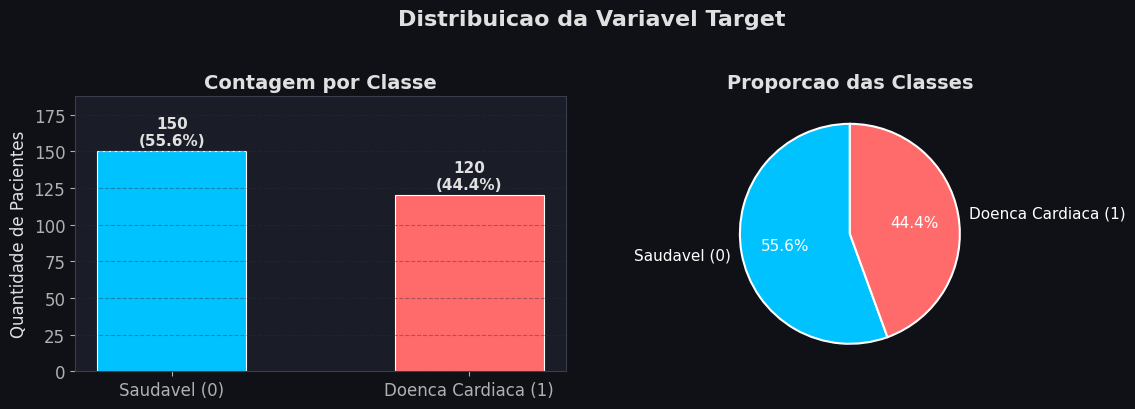

Distribuicao: 55.6% saudaveis / 44.4% com doenca cardiaca


In [6]:
# ------------------------------------------------------------------
# 3.2 Distribuicao da variavel target
#
# Verificamos o balanceamento das classes. Classes muito desbalanceadas
# exigem cuidados especiais na modelagem e escolha de metricas.
# AUC e a metrica mais indicada em cenarios de desbalanceamento leve/moderado.
# ------------------------------------------------------------------
target_counts = df['target'].value_counts().sort_index()
target_pct    = df['target'].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribuicao da Variavel Target', fontsize=16, fontweight='bold', y=1.02)

# Grafico de barras com contagem e percentual
labels = ['Saudavel (0)', 'Doenca Cardiaca (1)']
bars = axes[0].bar(labels, target_counts.values,
                   color=PALETTE[:2], edgecolor='white', linewidth=0.8, width=0.5)
for bar, val, pct in zip(bars, target_counts.values, target_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2.,
        bar.get_height() + 2,
        f'{val}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_title('Contagem por Classe')
axes[0].set_ylabel('Quantidade de Pacientes')
axes[0].grid(axis='y', alpha=0.4)
axes[0].set_ylim(0, target_counts.max() * 1.25)

# Grafico de pizza para proporcao visual
axes[1].pie(
    target_counts.values,
    labels=labels,
    colors=PALETTE[:2],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'color': 'white', 'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Proporcao das Classes')

plt.tight_layout()
plt.show()

print(f'Distribuicao: {target_pct[0]:.1f}% saudaveis / {target_pct[1]:.1f}% com doenca cardiaca')

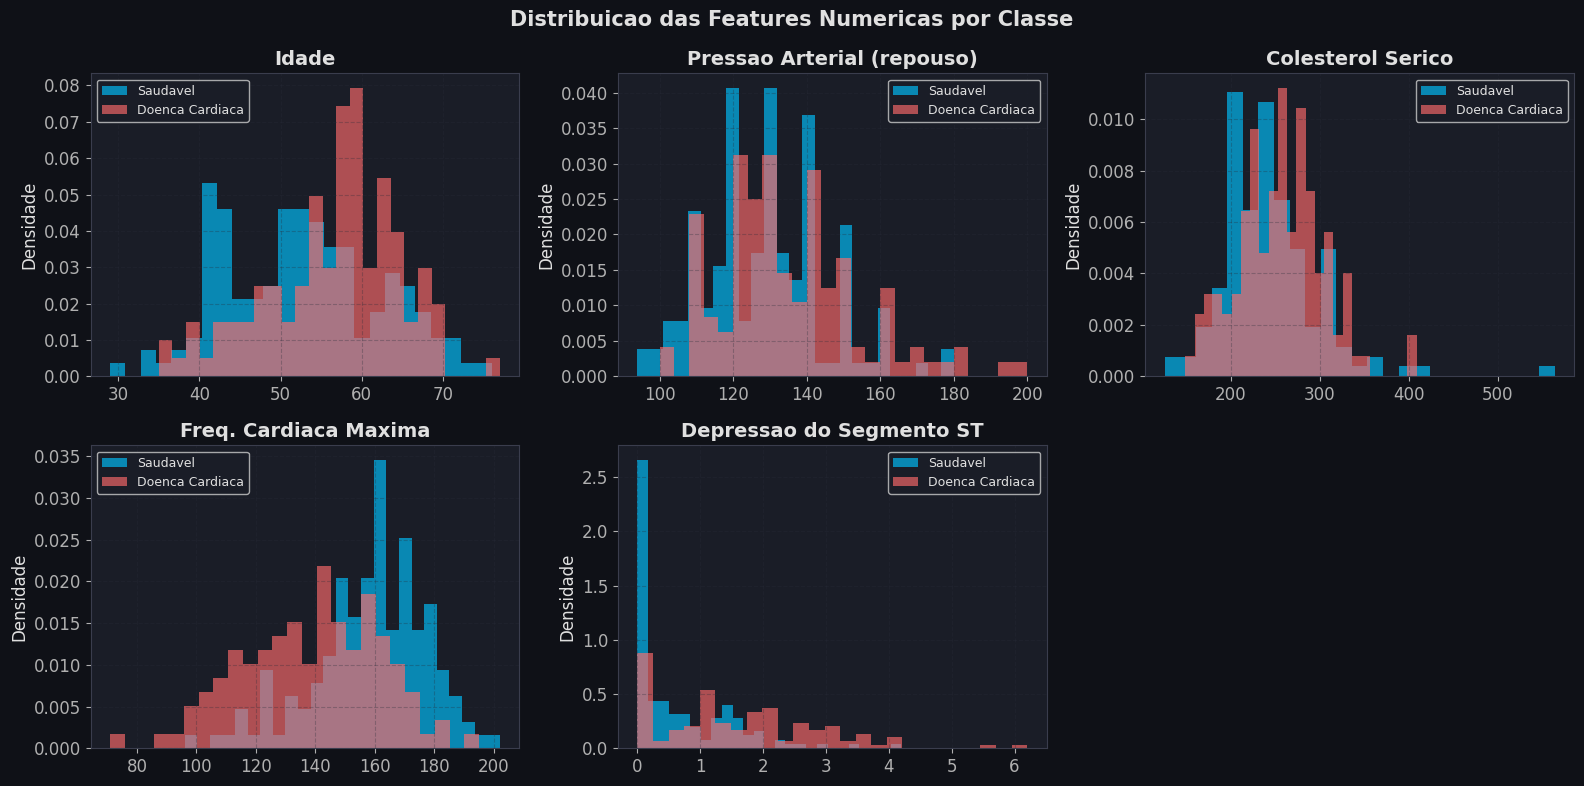

In [7]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 3.3 Distribuicao das features numericas por classe
#
# Histogramas sobrepostos por classe permitem identificar quais
# variaveis tem maior poder discriminativo visualmente.
# Uma boa feature separa bem as distribuicoes das duas classes.
# ------------------------------------------------------------------
features_num = ['age', 'resting_blood_pressure', 'serum_cholestoral', 'maximum_heart_rate_achieved', 'oldpeak']
feature_labels = {
    'age'      : 'Idade',
    'resting_blood_pressure' : 'Pressao Arterial (repouso)',
    'serum_cholestoral'     : 'Colesterol Serico',
    'maximum_heart_rate_achieved'  : 'Freq. Cardiaca Maxima',
    'oldpeak'  : 'Depressao do Segmento ST'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Distribuicao das Features Numericas por Classe', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(features_num):
    for cls, color, label in zip([0, 1], PALETTE[:2], ['Saudavel', 'Doenca Cardiaca']):
        data = df.loc[df['target'] == cls, feat].dropna()
        axes[i].hist(data, bins=25, alpha=0.65, color=color, label=label, density=True)
    axes[i].set_title(feature_labels.get(feat, feat))
    axes[i].set_ylabel('Densidade')
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

# Remove o subplot extra (grade 2x3 com 5 features)
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

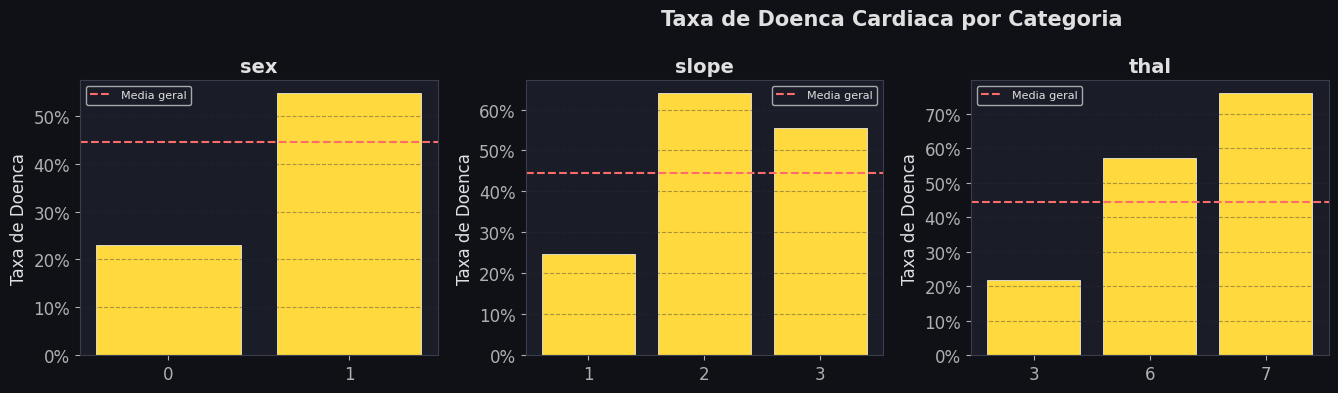

In [8]:
# ------------------------------------------------------------------
# 3.4 Distribuicao das features categoricas por classe
#
# Para variaveis categoricas, analisamos a taxa de evento (proporcao
# de pacientes doentes) dentro de cada categoria.
# Isso ajuda a identificar categorias com alto poder preditivo.
# ------------------------------------------------------------------
features_cat = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
features_cat = [f for f in features_cat if f in df.columns]

n_cols = 4
n_rows = int(np.ceil(len(features_cat) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
fig.suptitle('Taxa de Doenca Cardiaca por Categoria', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(features_cat):
    # Taxa de evento por categoria: media do target em cada grupo
    cross = df.groupby(col)['target'].mean().reset_index()
    cross.columns = [col, 'taxa_evento']

    axes[i].bar(
        cross[col].astype(str), cross['taxa_evento'],
        color=PALETTE[2], edgecolor='white', linewidth=0.5
    )
    # Linha de referencia: taxa media geral
    axes[i].axhline(
        y=df['target'].mean(),
        color=PALETTE[1], linestyle='--', linewidth=1.5,
        label='Media geral'
    )
    axes[i].set_title(col)
    axes[i].set_ylabel('Taxa de Doenca')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    axes[i].legend(fontsize=8)
    axes[i].grid(axis='y', alpha=0.4)

# Oculta subplots nao utilizados
for j in range(len(features_cat), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

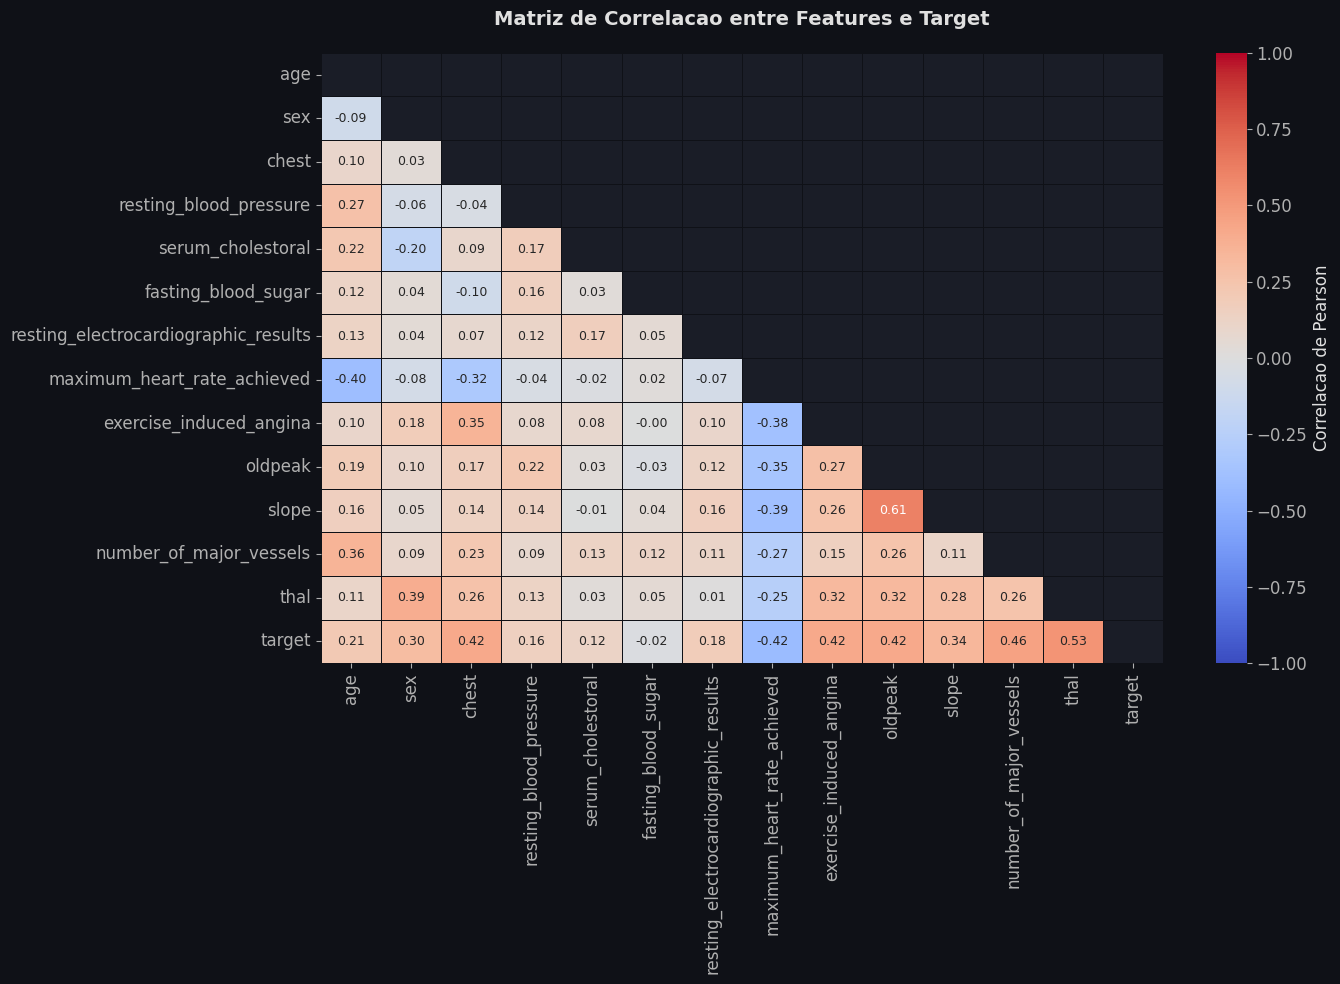

Top 10 features mais correlacionadas com o target (valor absoluto):
thal                                    0.525
number_of_major_vessels                 0.455
exercise_induced_angina                 0.419
maximum_heart_rate_achieved             0.419
oldpeak                                 0.418
chest                                   0.417
slope                                   0.338
sex                                     0.298
age                                     0.212
resting_electrocardiographic_results    0.182


In [9]:
# ------------------------------------------------------------------
# 3.5 Matriz de correlacao
#
# A matriz de correlacao de Pearson mede a relacao linear entre
# as variaveis numericas.
#
# Util para:
#   - Identificar features altamente correlacionadas entre si
#     (multicolinearidade), o que pode afetar modelos lineares
#   - Verificar quais features tem maior correlacao com o target
# ------------------------------------------------------------------
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))

# Mascara triangular superior para evitar redundancia
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, ax=ax,
    linewidths=0.4, linecolor='#0f1117',
    annot_kws={'size': 9},
    cbar_kws={'label': 'Correlacao de Pearson'}
)
ax.set_title('Matriz de Correlacao entre Features e Target', pad=20)
plt.tight_layout()
plt.show()

# Exibe as features mais correlacionadas com o target em ordem decrescente
print('Top 10 features mais correlacionadas com o target (valor absoluto):')
target_corr = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
print(target_corr.head(10).round(3).to_string())

## 4. Preparacao dos Dados

**Boas praticas aplicadas:**
- Remocao de duplicatas
- Imputacao de valores ausentes com mediana
- Clipping de outliers extremos (percentis 1 e 99)
- Split estratificado (70% treino / 15% validacao / 15% teste)
- Sem padronizacao das features (conforme definicao da aula)

In [11]:
# ------------------------------------------------------------------
# 4.1 Limpeza dos dados
# ------------------------------------------------------------------

# --- Remocao de duplicatas ---
# Registros identicos em todas as colunas sao redundantes e podem
# inflar artificialmente o desempenho do modelo.
n_before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicatas removidas: {n_before - len(df)}')

# --- Imputacao de valores ausentes ---
# Usamos a mediana por ser robusta a outliers.
# Em datasets pequenos, a imputacao e preferivel ao descarte de linhas.
null_before = df.isnull().sum().sum()
for col in df.columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)
print(f'Valores nulos imputados: {null_before}')

# --- Clipping de outliers extremos ---
# Limitamos os valores entre o percentil 1 e 99 para reduzir o
# impacto de valores extremos atipicos sem remover registros.
# Aplicado apenas em features continuas (exclui binarias e o target).
features_continuas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for col in features_continuas:
    if col in df.columns:
        p01 = df[col].quantile(0.01)
        p99 = df[col].quantile(0.99)
        df[col] = df[col].clip(p01, p99)

print(f'Clipping aplicado em {len(features_continuas)} features continuas (p1 a p99)')
print(f'Shape final: {df.shape}')

Duplicatas removidas: 0
Valores nulos imputados: 0
Clipping aplicado em 5 features continuas (p1 a p99)
Shape final: (270, 14)


In [12]:
# ------------------------------------------------------------------
# 4.2 Separacao de features (X) e target (y)
# ------------------------------------------------------------------
X = df.drop(columns=['target'])
y = df['target']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Proporcao target=1: {y.mean():.2%}')

X shape: (270, 13)
y shape: (270,)
Proporcao target=1: 44.44%


In [13]:
# ------------------------------------------------------------------
# 4.3 Split estratificado: Treino / Teste
#
# O split ESTRATIFICADO garante que a proporcao entre classes seja
# mantida em ambos os subconjuntos, evitando vieses de amostragem.
#
# Proporcoes: 70% treino | 30% teste
#
# REGRA FUNDAMENTAL: O conjunto de teste e selado aqui e so sera
# utilizado na avaliacao final. Qualquer uso antes disso constitui
# data leakage e invalida os resultados.
# ------------------------------------------------------------------

# Realiza a divisao principal em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, # 30% para teste
    stratify=y,
    random_state=SEED
)

print('Divisao dos dados:')
print(f'  Treino    : {len(X_train):>4} amostras ({len(X_train)/len(X):.1%})  |  target=1: {y_train.mean():.2%}')
print(f'  Teste     : {len(X_test):>4} amostras ({len(X_test)/len(X):.1%})  |  target=1: {y_test.mean():.2%}')
print()
print('Conjunto de TESTE selado. Sera aberto somente na avaliacao final.')

Divisao dos dados:
  Treino    :  189 amostras (70.0%)  |  target=1: 44.44%
  Teste     :   81 amostras (30.0%)  |  target=1: 44.44%

Conjunto de TESTE selado. Sera aberto somente na avaliacao final.


## 5. Tuning de Hiperparametros com Optuna + Validacao Cruzada

**Estrategia:**

Para cada modelo, o Optuna cria um `study` que, a cada `trial`, propoe um conjunto de hiperparametros e avalia a **AUC media em validacao cruzada estratificada** (StratifiedKFold com 5 folds) sobre o conjunto de treino.

O uso de validacao cruzada no tuning e mais robusto do que uma unica divisao treino/validacao porque:
- Reduz a variancia da estimativa de desempenho
- Aproveita todos os dados de treino para avaliacao
- Diminui o risco de overfitting ao conjunto de validacao

In [14]:
# ------------------------------------------------------------------
# 5.0 Configuracao global do processo de tuning
# ------------------------------------------------------------------

# Numero de trials por modelo.
# Cada trial e uma tentativa do Optuna com um conjunto diferente de hiperparametros.
# Aumente para 100+ em producao; 30-50 e adequado para uma aula.
N_TRIALS = 20

# Configuracao do K-Fold estratificado.
# shuffle=True garante que os dados sejam embaralhados antes de dividir.
CV_FOLDS = 5
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

# Dicionario para armazenar os melhores resultados de cada modelo
results = {}

print('Configuracao do tuning:')
print(f'  Trials por modelo : {N_TRIALS}')
print(f'  Folds de CV       : {CV_FOLDS}')
print(f'  Sampler           : TPE (Tree-structured Parzen Estimator)')
print(f'    > TPE é um algoritmo de busca bayesiana que modela as distribuições de bons e maus hiperparâmetros para guiar a busca de forma mais eficiente.')
print(f'  Metrica           : AUC-ROC (media dos folds)')
print(f'  Objetivo          : Maximizar AUC')

Configuracao do tuning:
  Trials por modelo : 20
  Folds de CV       : 5
  Sampler           : TPE (Tree-structured Parzen Estimator)
    > TPE é um algoritmo de busca bayesiana que modela as distribuições de bons e maus hiperparâmetros para guiar a busca de forma mais eficiente.
  Metrica           : AUC-ROC (media dos folds)
  Objetivo          : Maximizar AUC


In [15]:
# ------------------------------------------------------------------
# 5.1 XGBoost
#
# Gradient boosting baseado em arvores com regularizacao L1/L2.
# Hiperparametros principais:
#   - n_estimators    : numero de arvores (boosting rounds)
#   - max_depth       : profundidade maxima de cada arvore
#   - learning_rate   : taxa de aprendizado (shrinkage)
#   - subsample       : fracao de amostras por arvore (reduz overfitting)
#   - colsample_bytree: fracao de features por arvore
#   - gamma           : ganho minimo para particionar um no
#   - reg_alpha/lambda: regularizacao L1 e L2
# ------------------------------------------------------------------
def objective_xgb(trial):
    # O Optuna sugere valores para cada hiperparametro dentro dos intervalos definidos
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 50, 500),
        'max_depth'        : trial.suggest_int('max_depth', 2, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'eval_metric'      : 'auc',
        'random_state'     : SEED,
        'n_jobs'           : -1,
    }
    model = xgb.XGBClassifier(**params)

    # Avalia o modelo com validacao cruzada sobre o conjunto de treino.
    # scoring='roc_auc' calcula a AUC em cada fold; retornamos a media.
    auc_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    return auc_scores.mean()

print('Iniciando otimizacao do XGBoost...')
study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)
results['XGBoost'] = {'best_params': study_xgb.best_params, 'best_auc': study_xgb.best_value}
print(f'XGBoost concluido | Melhor AUC (CV): {study_xgb.best_value:.4f}')

Iniciando otimizacao do XGBoost...


  0%|          | 0/20 [00:00<?, ?it/s]

XGBoost concluido | Melhor AUC (CV): 0.8958


In [16]:
# ------------------------------------------------------------------
# 5.2 LightGBM
#
# Gradient boosting baseado em histograma. Geralmente mais rapido
# que o XGBoost em datasets grandes.
# Hiperparametro exclusivo relevante:
#   - num_leaves: numero maximo de folhas por arvore.
#     Controla a complexidade do modelo de forma diferente do max_depth.
#     A relacao recomendada e: num_leaves < 2^max_depth
#   - min_child_samples: minimo de amostras em uma folha (regularizacao)
# ------------------------------------------------------------------
def objective_lgb(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 50, 500),
        'max_depth'         : trial.suggest_int('max_depth', 2, 12),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'        : trial.suggest_int('num_leaves', 10, 150),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples' : trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state'      : SEED,
        'n_jobs'            : -1,
        'verbose'           : -1,
    }
    model = lgb.LGBMClassifier(**params)
    auc_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    return auc_scores.mean()

print('Iniciando otimizacao do LightGBM...')
study_lgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS, show_progress_bar=True)
results['LightGBM'] = {'best_params': study_lgb.best_params, 'best_auc': study_lgb.best_value}
print(f'LightGBM concluido | Melhor AUC (CV): {study_lgb.best_value:.4f}')

Iniciando otimizacao do LightGBM...


  0%|          | 0/20 [00:00<?, ?it/s]

LightGBM concluido | Melhor AUC (CV): 0.9044


In [17]:
# ------------------------------------------------------------------
# 5.3 Random Forest
#
# Ensemble de arvores de decisao treinadas em subamostras aleatorias
# com selecao aleatoria de features (Bagging + Feature Subsampling).
# Mais robusto ao overfitting do que uma unica arvore.
# Hiperparametros relevantes:
#   - max_features: fracao de features avaliadas em cada split
#   - class_weight: estrategia para lidar com desbalanceamento
# ------------------------------------------------------------------
def objective_rf(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 50, 500),
        'max_depth'       : trial.suggest_int('max_depth', 2, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'    : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight'    : trial.suggest_categorical('class_weight', ['balanced', None]),
        'random_state'    : SEED,
        'n_jobs'          : -1,
    }
    model = RandomForestClassifier(**params)
    auc_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    return auc_scores.mean()

print('Iniciando otimizacao do Random Forest...')
study_rf = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study_rf.optimize(objective_rf, n_trials=N_TRIALS, show_progress_bar=True)
results['Random Forest'] = {'best_params': study_rf.best_params, 'best_auc': study_rf.best_value}
print(f'Random Forest concluido | Melhor AUC (CV): {study_rf.best_value:.4f}')

Iniciando otimizacao do Random Forest...


  0%|          | 0/20 [00:00<?, ?it/s]

Random Forest concluido | Melhor AUC (CV): 0.9055


In [18]:
# ------------------------------------------------------------------
# 5.4 Arvore de Decisao
#
# Modelo interpretavel baseado em regras de particao recursiva.
# Alta capacidade de overfitting; o controle de profundidade e
# o hiperparametro mais critico.
# Incluido na comparacao por seu valor didatico e interpretabilidade.
# ------------------------------------------------------------------
def objective_dt(trial):
    params = {
        'max_depth'        : trial.suggest_int('max_depth', 2, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 30),
        'criterion'        : trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'class_weight'     : trial.suggest_categorical('class_weight', ['balanced', None]),
        'random_state'     : SEED,
    }
    model = DecisionTreeClassifier(**params)
    auc_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    return auc_scores.mean()

print('Iniciando otimizacao da Arvore de Decisao...')
study_dt = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study_dt.optimize(objective_dt, n_trials=N_TRIALS, show_progress_bar=True)
results['Arvore de Decisao'] = {'best_params': study_dt.best_params, 'best_auc': study_dt.best_value}
print(f'Arvore de Decisao concluida | Melhor AUC (CV): {study_dt.best_value:.4f}')

Iniciando otimizacao da Arvore de Decisao...


  0%|          | 0/20 [00:00<?, ?it/s]

Arvore de Decisao concluida | Melhor AUC (CV): 0.8399


In [19]:
# ------------------------------------------------------------------
# 5.5 Regressao Logistica
#
# Modelo linear probabilistico, baseline classico de classificacao.
# Altamente interpretavel; assume relacao linear entre features e log-odds.
# Hiperparametros relevantes:
#   - C          : inverso da regularizacao (C pequeno = mais regularizacao)
#   - penalty    : tipo de regularizacao (L1 promove sparsidade; L2 encolhe)
#   - solver=saga: unico solver que suporta tanto L1 quanto L2
# ------------------------------------------------------------------
def objective_lr(trial):
    params = {
        'C'           : trial.suggest_float('C', 1e-3, 100.0, log=True),
        'penalty'     : trial.suggest_categorical('penalty', ['l1', 'l2']),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', None]),
        'solver'      : 'saga',   # suporta L1 e L2; bom para datasets medios
        'max_iter'    : 2000,     # aumentado para garantir convergencia
        'random_state': SEED,
        'n_jobs'      : -1,
    }
    model = LogisticRegression(**params)
    auc_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    return auc_scores.mean()

print('Iniciando otimizacao da Regressao Logistica...')
study_lr = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study_lr.optimize(objective_lr, n_trials=N_TRIALS, show_progress_bar=True)
results['Regressao Logistica'] = {'best_params': study_lr.best_params, 'best_auc': study_lr.best_value}
print(f'Regressao Logistica concluida | Melhor AUC (CV): {study_lr.best_value:.4f}')

Iniciando otimizacao da Regressao Logistica...


  0%|          | 0/20 [00:00<?, ?it/s]

Regressao Logistica concluida | Melhor AUC (CV): 0.8609


## 6. Comparacao e Selecao do Melhor Modelo

In [20]:
# ------------------------------------------------------------------
# 6.1 Tabela comparativa de desempenho na validacao cruzada
#
# Criterio de selecao: maior AUC media nos 5 folds de CV.
# Este valor e uma estimativa do desempenho esperado no teste,
# mas nao e o valor exato — ha variancia natural entre folds.
# ------------------------------------------------------------------
comparison_df = pd.DataFrame([
    {'Modelo': name, 'AUC CV': round(info['best_auc'], 4)}
    for name, info in results.items()
]).sort_values('AUC CV', ascending=False).reset_index(drop=True)

comparison_df.insert(0, 'Rank', range(1, len(comparison_df) + 1))

print('=' * 50)
print('RANKING — AUC media (Validacao Cruzada 5-Fold)')
print('=' * 50)
print(comparison_df.to_string(index=False))
print('=' * 50)

# O melhor modelo e aquele com maior AUC media na CV
best_model_name = comparison_df.iloc[0]['Modelo']
best_auc_cv     = comparison_df.iloc[0]['AUC CV']
print(f'\nModelo selecionado: {best_model_name} (AUC CV = {best_auc_cv:.4f})')

RANKING — AUC media (Validacao Cruzada 5-Fold)
 Rank              Modelo  AUC CV
    1       Random Forest  0.9055
    2            LightGBM  0.9044
    3             XGBoost  0.8958
    4 Regressao Logistica  0.8609
    5   Arvore de Decisao  0.8399

Modelo selecionado: Random Forest (AUC CV = 0.9055)


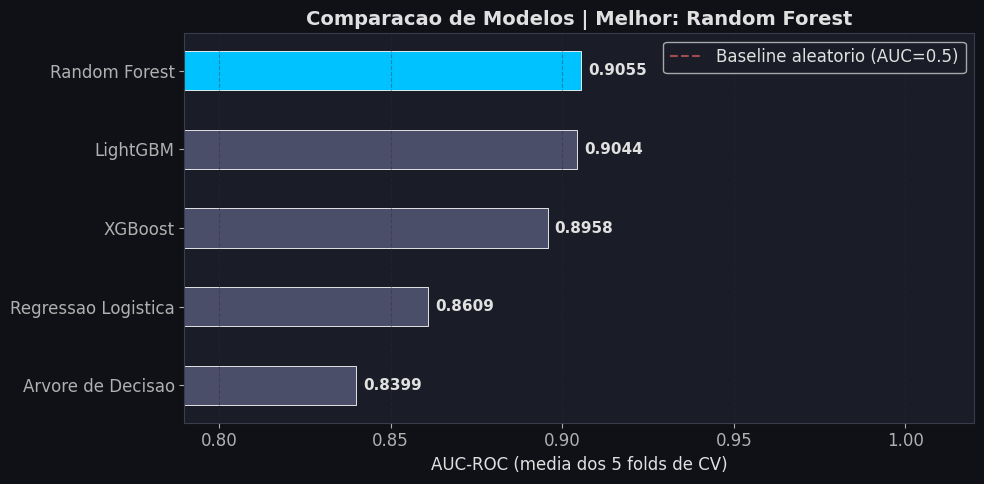

In [21]:
# ------------------------------------------------------------------
# 6.2 Grafico comparativo entre modelos
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

# Destaca o melhor modelo em azul; os demais ficam em cinza
bar_colors = [
    PALETTE[0] if m == best_model_name else '#4a4e69'
    for m in comparison_df['Modelo']
]

bars = ax.barh(
    comparison_df['Modelo'], comparison_df['AUC CV'],
    color=bar_colors, edgecolor='white', linewidth=0.6, height=0.5
)

# Rotula cada barra com o valor de AUC
for bar, val in zip(bars, comparison_df['AUC CV']):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', fontsize=11, fontweight='bold'
    )

ax.set_xlim(comparison_df['AUC CV'].min() - 0.05, 1.02)
ax.set_xlabel('AUC-ROC (media dos 5 folds de CV)')
ax.set_title(f'Comparacao de Modelos | Melhor: {best_model_name}')

# Linha de referencia: baseline aleatorio
ax.axvline(x=0.5, color=PALETTE[1], linestyle='--', alpha=0.6, label='Baseline aleatorio (AUC=0.5)')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

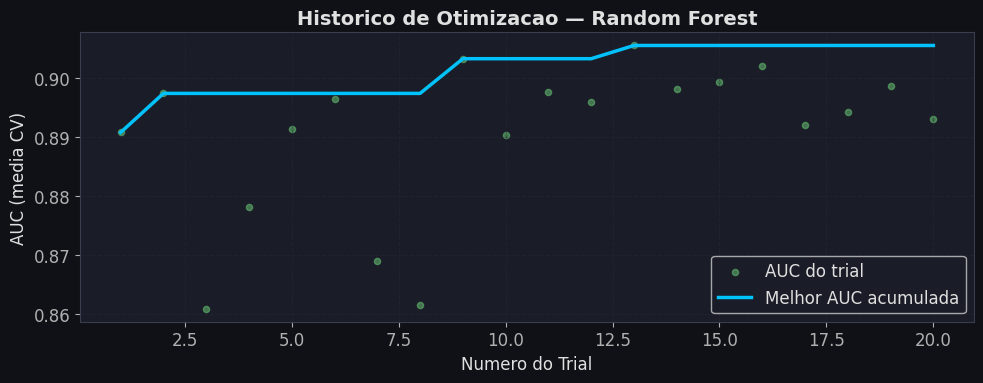

Melhores hiperparametros encontrados para Random Forest:
  n_estimators             : 55
  max_depth                : 15
  min_samples_split        : 8
  min_samples_leaf         : 8
  max_features             : sqrt
  class_weight             : None


In [22]:
# ------------------------------------------------------------------
# 6.3 Historico de otimizacao do melhor modelo
#
# O grafico de convergencia mostra como a AUC evoluiu ao longo
# dos trials. Permite verificar se o tuning convergiu ou se
# seria necessario mais trials.
# ------------------------------------------------------------------

# Recupera o study correspondente ao melhor modelo
study_map = {
    'XGBoost'            : study_xgb,
    'LightGBM'           : study_lgb,
    'Random Forest'      : study_rf,
    'Arvore de Decisao'  : study_dt,
    'Regressao Logistica': study_lr,
}
best_study = study_map[best_model_name]

# Extrai AUC de cada trial e calcula o maximo acumulado (melhor visto ate agora)
trial_aucs   = [t.value for t in best_study.trials]
best_so_far  = np.maximum.accumulate(trial_aucs)

fig, ax = plt.subplots(figsize=(10, 4))

# Pontos: AUC de cada trial individual
ax.scatter(range(1, len(trial_aucs) + 1), trial_aucs,
           color=PALETTE[3], alpha=0.5, s=20, label='AUC do trial')

# Linha: melhor AUC acumulada (curva de convergencia)
ax.plot(range(1, len(best_so_far) + 1), best_so_far,
        color=PALETTE[0], linewidth=2.5, label='Melhor AUC acumulada')

ax.set_xlabel('Numero do Trial')
ax.set_ylabel('AUC (media CV)')
ax.set_title(f'Historico de Otimizacao — {best_model_name}')
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

print(f'Melhores hiperparametros encontrados para {best_model_name}:')
for k, v in results[best_model_name]['best_params'].items():
    print(f'  {k:<25}: {v}')

## 7. Treinamento Final e Avaliacao no Conjunto de Teste

> **Abrindo o conjunto de teste.**  
> O modelo final e retreinado com os melhores hiperparametros sobre **treino + validacao**
> Este e o unico momento em que o teste e utilizado.

In [23]:
# ------------------------------------------------------------------
# 7.1 Predicoes e metricas no conjunto de teste
#
# predict_proba retorna a probabilidade para cada classe.
# Usamos a coluna [:, 1] que representa P(classe=1).
#
# Threshold = 0.5 e o padrao; pode ser ajustado conforme o custo
# relativo de falsos positivos vs falsos negativos no contexto.
# ------------------------------------------------------------------

# --- Treinamento Final Simplificado do melhor modelo (Random Forest) ---

# Obtem os melhores parametros para o Random Forest
best_params_rf = results['Random Forest']['best_params']

# Instancia e treina o modelo Random Forest com os melhores hiperparametros
final_model = RandomForestClassifier(
    **best_params_rf,
    random_state=SEED,
    n_jobs=-1
)
final_model.fit(X_train, y_train)

print(f'Modelo final (Random Forest) treinado em {len(X_train)} amostras.')
print('=' * 55)

y_prob_test = final_model.predict_proba(X_test)[:, 1]

THRESHOLD = 0.5
y_pred_test = (y_prob_test >= THRESHOLD).astype(int)

# Calculo das metricas
auc_test  = roc_auc_score(y_test, y_prob_test)
acc_test  = accuracy_score(y_test, y_pred_test)
f1_test   = f1_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test)
rec_test  = recall_score(y_test, y_pred_test)

print(f'METRICAS FINAIS NO TESTE — Random Forest')
print('=' * 55)
print(f'  AUC (ROC)  : {auc_test:.4f}')
print(f'  Acuracia   : {acc_test:.4f}')
print(f'  F1-Score   : {f1_test:.4f}')
print(f'  Precisao   : {prec_test:.4f}')
print(f'  Recall     : {rec_test:.4f}')
print('=' * 55)
print()
print('Relatorio de Classificacao completo:')
print(classification_report(
    y_test, y_pred_test,
    target_names=['Saudavel (0)', 'Doenca Cardiaca (1)']
))

Modelo final (Random Forest) treinado em 189 amostras.
METRICAS FINAIS NO TESTE — Random Forest
  AUC (ROC)  : 0.9241
  Acuracia   : 0.8889
  F1-Score   : 0.8767
  Precisao   : 0.8649
  Recall     : 0.8889

Relatorio de Classificacao completo:
                     precision    recall  f1-score   support

       Saudavel (0)       0.91      0.89      0.90        45
Doenca Cardiaca (1)       0.86      0.89      0.88        36

           accuracy                           0.89        81
          macro avg       0.89      0.89      0.89        81
       weighted avg       0.89      0.89      0.89        81



## 8. Visualizacoes de Avaliacao

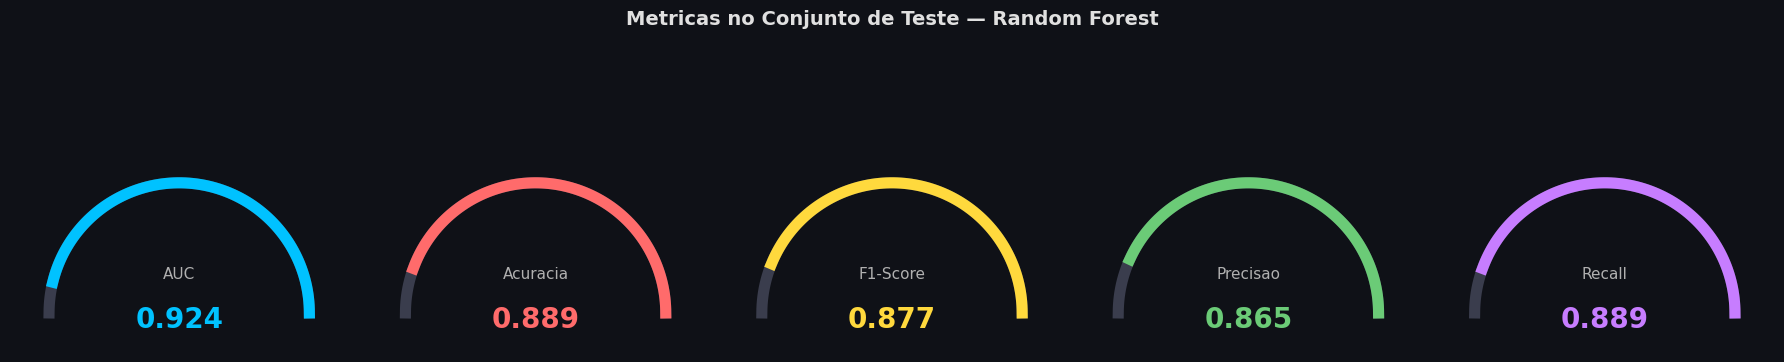

In [24]:
# ------------------------------------------------------------------
# 8.1 Painel de metricas
#
# Visualizacao em forma de gauges (semicirculos) para leitura
# rapida das metricas principais no conjunto de teste.
#
# Interpretacao:
#   AUC      : capacidade discriminativa geral do modelo
#   Acuracia : proporcao de acertos total
#   F1-Score : media harmonica entre precisao e recall
#   Precisao : dos preditos como positivos, quantos realmente sao
#   Recall   : dos positivos reais, quantos o modelo detectou
# ------------------------------------------------------------------
metrics = {
    'AUC'      : auc_test,
    'Acuracia' : acc_test,
    'F1-Score' : f1_test,
    'Precisao' : prec_test,
    'Recall'   : rec_test
}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle(
    f'Metricas no Conjunto de Teste — {best_model_name}',
    fontsize=14, fontweight='bold', y=1.05
)

for ax, (name, val), color in zip(axes, metrics.items(), PALETTE):
    ax.set_facecolor('#1a1d27')
    # Arco de fundo (cinza) representando o maximo
    theta_full = np.linspace(0, np.pi, 100)
    ax.plot(np.cos(theta_full), np.sin(theta_full),
            color='#3a3d4d', linewidth=8)
    # Arco colorido proporcional ao valor da metrica
    theta_val = np.linspace(0, np.pi * val, 100)
    ax.plot(np.cos(theta_val), np.sin(theta_val),
            color=color, linewidth=8)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.set_aspect('equal')
    ax.axis('off')
    # Valor numerico no centro
    ax.text(0, -0.05, f'{val:.3f}',
            ha='center', va='center',
            fontsize=20, fontweight='bold', color=color)
    # Nome da metrica abaixo
    ax.text(0, 0.3, name,
            ha='center', va='center',
            fontsize=11, color='#b0b0b0')

plt.tight_layout()
plt.show()

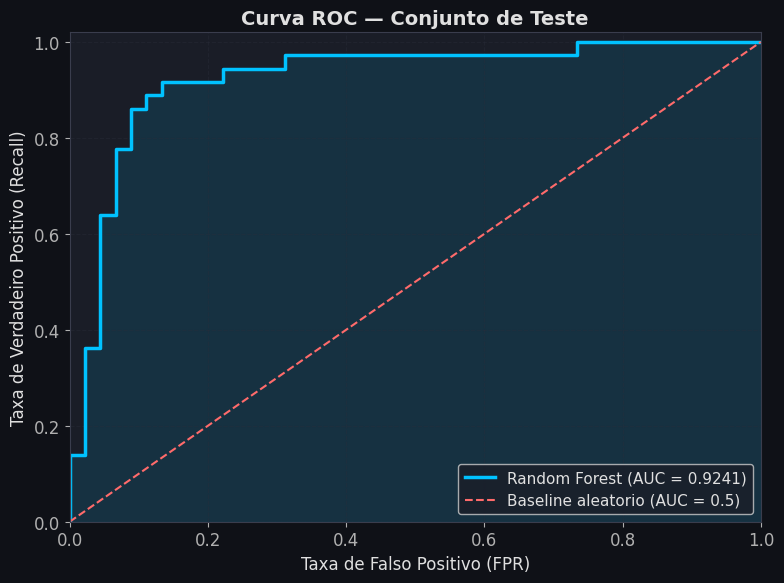

In [25]:
# ------------------------------------------------------------------
# 8.2 Curva ROC
#
# A curva ROC plota Recall (TPR) vs Taxa de Falso Positivo (FPR)
# para todos os possiveis thresholds.
#
# A AUC representa a area sob essa curva:
#   0.5 = modelo aleatorio (diagonal)
#   1.0 = modelo perfeito
# ------------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color=PALETTE[0], linewidth=2.5,
        label=f'{best_model_name} (AUC = {auc_test:.4f})')
ax.plot([0, 1], [0, 1], color=PALETTE[1], linestyle='--',
        linewidth=1.5, label='Baseline aleatorio (AUC = 0.5)')

# Sombreamento da area sob a curva para facilitar a interpretacao visual
ax.fill_between(fpr, tpr, alpha=0.12, color=PALETTE[0])

ax.set_xlabel('Taxa de Falso Positivo (FPR)')
ax.set_ylabel('Taxa de Verdadeiro Positivo (Recall)')
ax.set_title('Curva ROC — Conjunto de Teste')
ax.legend(fontsize=11)
ax.grid(alpha=0.4)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

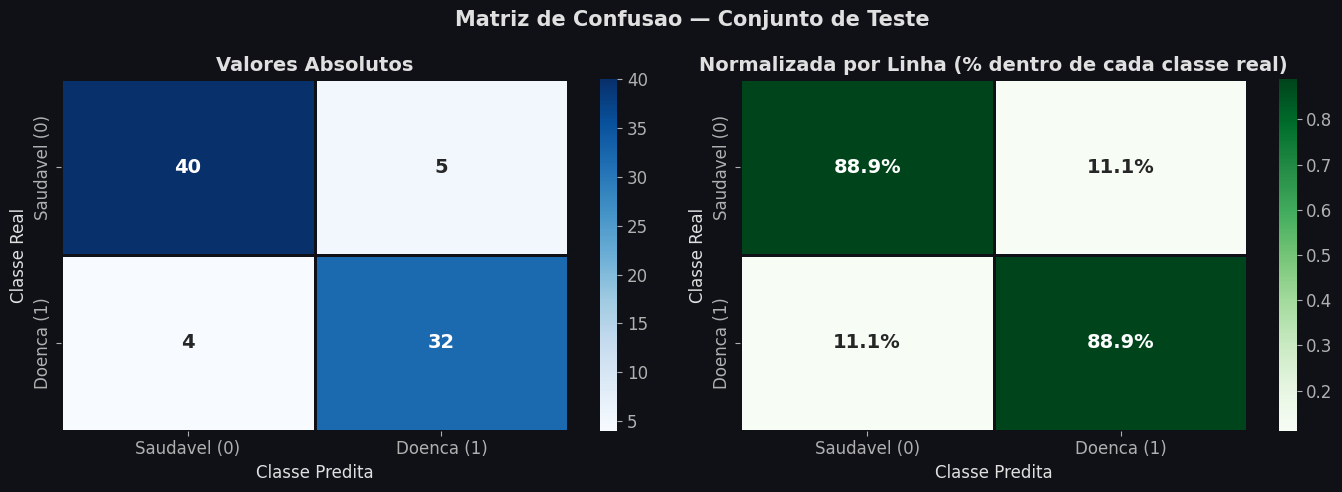

Decomposicao da matriz:
  VP (True Positive)  :  32  — doentes corretamente identificados
  VN (True Negative)  :  40  — saudaveis corretamente identificados
  FP (False Positive) :   5  — saudaveis classificados como doentes
  FN (False Negative) :   4  — doentes classificados como saudaveis (erro mais critico)


In [26]:
# ------------------------------------------------------------------
# 8.3 Matriz de confusao
#
# A matriz de confusao mostra os 4 tipos de resultado:
#   VP (Verdadeiro Positivo) : doente corretamente identificado
#   VN (Verdadeiro Negativo) : saudavel corretamente identificado
#   FP (Falso Positivo)      : saudavel classificado como doente
#   FN (Falso Negativo)      : doente classificado como saudavel
#
# No contexto medico, o FN e geralmente o erro mais critico,
# pois um doente nao diagnosticado nao recebera tratamento.
# ------------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred_test)

# Matriz normalizada por linha: proporcao dentro de cada classe real
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Matriz de Confusao — Conjunto de Teste', fontsize=15, fontweight='bold')

class_labels = ['Saudavel (0)', 'Doenca (1)']

# Versao com valores absolutos
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=class_labels, yticklabels=class_labels,
    linewidths=1, linecolor='#0f1117',
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_title('Valores Absolutos')
axes[0].set_ylabel('Classe Real')
axes[0].set_xlabel('Classe Predita')

# Versao normalizada por linha (proporcao dentro de cada classe)
sns.heatmap(
    cm_norm, annot=True, fmt='.1%', cmap='Greens', ax=axes[1],
    xticklabels=class_labels, yticklabels=class_labels,
    linewidths=1, linecolor='#0f1117',
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[1].set_title('Normalizada por Linha (% dentro de cada classe real)')
axes[1].set_ylabel('Classe Real')
axes[1].set_xlabel('Classe Predita')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print('Decomposicao da matriz:')
print(f'  VP (True Positive)  : {tp:3d}  — doentes corretamente identificados')
print(f'  VN (True Negative)  : {tn:3d}  — saudaveis corretamente identificados')
print(f'  FP (False Positive) : {fp:3d}  — saudaveis classificados como doentes')
print(f'  FN (False Negative) : {fn:3d}  — doentes classificados como saudaveis (erro mais critico)')

In [ ]:
# ------------------------------------------------------------------
# 8.4 Distribuicao do score por classe real
#
# Esta visualizacao mostra a distribuicao da probabilidade predita
# (score) separada por classe real (0 ou 1).
#
# Um bom modelo deve ter:
#   - Distribuicao da classe 0 concentrada perto de 0
#   - Distribuicao da classe 1 concentrada perto de 1
#   - Pouca sobreposicao entre as duas distribuicoes
# ------------------------------------------------------------------
scores_0 = y_prob_test[y_test.values == 0]
scores_1 = y_prob_test[y_test.values == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuicao do Score (P(doenca)) por Classe Real', fontsize=14, fontweight='bold')

# --- Histograma sobrepostos ---
# Permite comparar diretamente a sobreposicao entre as duas classes
axes[0].hist(scores_0, bins=30, alpha=0.65, color=PALETTE[0],
             label='Saudavel (0)', density=True)
axes[0].hist(scores_1, bins=30, alpha=0.65, color=PALETTE[1],
             label='Doenca Cardiaca (1)', density=True)
axes[0].axvline(x=THRESHOLD, color=PALETTE[2], linestyle='--',
                linewidth=2, label=f'Threshold = {THRESHOLD}')
axes[0].set_xlabel('Score (probabilidade predita)')
axes[0].set_ylabel('Densidade')
axes[0].set_title('Histograma de Scores por Classe')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Boxplot por classe ---
# Mostra mediana, quartis e outliers da distribuicao de scores
for i, (data_cls, color, lbl) in enumerate(zip(
    [scores_0, scores_1],
    PALETTE[:2],
    ['Saudavel (0)', 'Doenca Cardiaca (1)']
)):
    bp = axes[1].boxplot(
        data_cls, positions=[i], widths=0.4,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color='white', linewidth=2.5),
        whiskerprops=dict(color=color, linewidth=1.5),
        capprops=dict(color=color, linewidth=1.5),
        flierprops=dict(markerfacecolor=color, markersize=3, alpha=0.4)
    )

axes[1].axhline(y=THRESHOLD, color=PALETTE[2], linestyle='--',
                linewidth=2, label=f'Threshold = {THRESHOLD}')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Saudavel (0)', 'Doenca Cardiaca (1)'])
axes[1].set_ylabel('Score (probabilidade predita)')
axes[1].set_title('Boxplot de Scores por Classe')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Score medio — Saudaveis        (0): {scores_0.mean():.3f}')
print(f'Score medio — Doenca cardiaca  (1): {scores_1.mean():.3f}')
print(f'Separacao media dos scores        : {scores_1.mean() - scores_0.mean():.3f}')
print('(Quanto maior a separacao, melhor o modelo discrimina as classes)')

In [27]:
# ------------------------------------------------------------------
# 8.5 Concentracao da target por decil
#
# Analise de decis: ordenamos os pacientes pelo score em ordem
# decrescente e dividimos em 10 grupos iguais (decis).
#
# O decil 1 contem os pacientes com maior probabilidade predita
# de ter doenca cardiaca.
#
# Esta analise e fundamental em problemas de negocio onde e
# necessario priorizar acoes (ex: quais pacientes chamar primeiro
# para exames complementares).
#
# Metricas calculadas por decil:
#   taxa_evento  : proporcao de doentes dentro do decil
#   lift         : razao entre a taxa do decil e a taxa media geral
#                  lift > 1 significa que o decil e mais rico em doentes
#                  do que uma selecao aleatoria
#   pct_eventos_acum: porcentagem cumulativa de doentes capturados
# ------------------------------------------------------------------
df_decil = pd.DataFrame({
    'score' : y_prob_test,
    'target': y_test.values
})

# Divide em decis com base no score; duplicates='drop' evita erros
# quando ha muitos valores repetidos
df_decil['decil'] = pd.qcut(
    df_decil['score'], q=10, labels=False, duplicates='drop'
)
# Reinverte para que decil 1 = maior score
df_decil['decil'] = 10 - df_decil['decil']

# Agrega as metricas por decil
decil_summary = (
    df_decil.groupby('decil')
    .agg(
        total       = ('target', 'count'),
        n_eventos   = ('target', 'sum'),
        score_min   = ('score', 'min'),
        score_max   = ('score', 'max'),
        score_medio = ('score', 'mean'),
    )
    .reset_index()
)

taxa_media_geral = df_decil['target'].mean()

decil_summary['taxa_evento']      = decil_summary['n_eventos'] / decil_summary['total']
decil_summary['lift']             = decil_summary['taxa_evento'] / taxa_media_geral
decil_summary['pct_eventos_acum'] = decil_summary['n_eventos'].cumsum() / decil_summary['n_eventos'].sum() * 100
decil_summary['pct_pop_acum']     = decil_summary['total'].cumsum() / decil_summary['total'].sum() * 100

print('=' * 80)
print('ANALISE DE DECIS — Concentracao da Target')
print('=' * 80)
print(
    decil_summary[[
        'decil', 'total', 'n_eventos', 'taxa_evento',
        'lift', 'score_min', 'score_max', 'pct_eventos_acum'
    ]].rename(columns={
        'decil'           : 'Decil',
        'total'           : 'Total',
        'n_eventos'       : 'Doentes',
        'taxa_evento'     : 'Taxa',
        'lift'            : 'Lift',
        'score_min'       : 'Score Min',
        'score_max'       : 'Score Max',
        'pct_eventos_acum': '% Doentes Acum'
    }).to_string(index=False, float_format=lambda x: f'{x:.3f}')
)

ANALISE DE DECIS — Concentracao da Target
 Decil  Total  Doentes  Taxa  Lift  Score Min  Score Max  % Doentes Acum
     1      8        7 0.875 1.969      0.841      0.969          19.444
     2      8        7 0.875 1.969      0.728      0.834          38.889
     3      8        8 1.000 2.250      0.693      0.724          61.111
     4      8        6 0.750 1.688      0.563      0.690          77.778
     5      8        5 0.625 1.406      0.478      0.551          91.667
     6      8        1 0.125 0.281      0.379      0.450          94.444
     7      8        1 0.125 0.281      0.271      0.375          97.222
     8      8        0 0.000 0.000      0.223      0.271          97.222
     9      8        1 0.125 0.281      0.163      0.215         100.000
    10      9        0 0.000 0.000      0.038      0.151         100.000


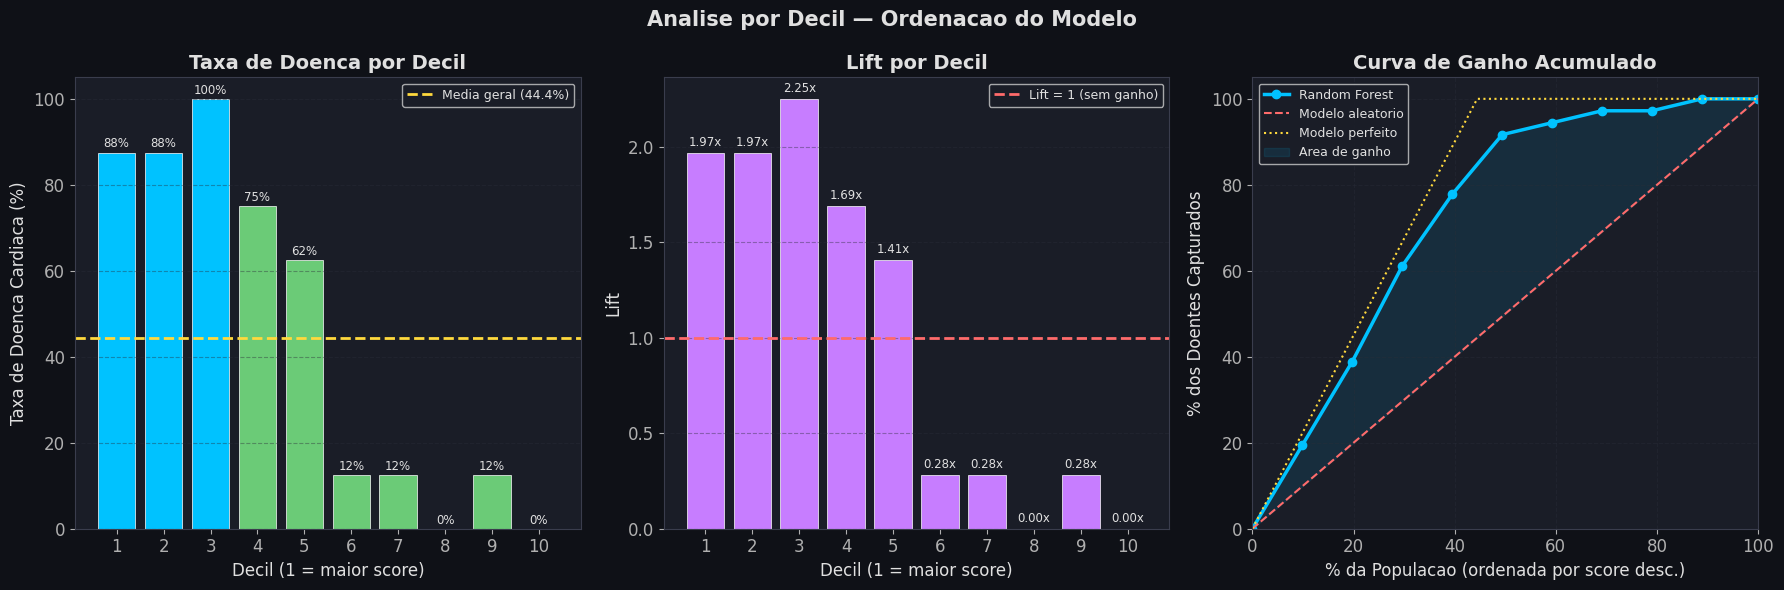

Interpretacao da curva de ganho:
  Abordando o 1 decil (10% da populacao) -> 19.4% dos doentes capturados
  Abordando os 3 decis (30% da populacao) -> 61.1% dos doentes capturados


In [28]:
# ------------------------------------------------------------------
# 8.6 Graficos de analise por decil
#
# Tres perspectivas complementares:
#   (a) Taxa de evento por decil: mostra a concentracao de doentes
#   (b) Lift por decil: compara cada decil contra o baseline aleatorio
#   (c) Curva de ganho acumulado: mostra quantos doentes sao capturados
#       ao abordar X% da populacao ordenada por score
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Analise por Decil — Ordenacao do Modelo', fontsize=15, fontweight='bold')

x_labels = decil_summary['decil'].astype(str)

# --- (a) Taxa de evento por decil ---
bar_colors_decil = [
    PALETTE[0] if i < 3 else PALETTE[3]
    for i in range(len(x_labels))
]
bars_a = axes[0].bar(
    x_labels, decil_summary['taxa_evento'] * 100,
    color=bar_colors_decil, edgecolor='white', linewidth=0.5
)
# Linha da taxa media geral como referencia
axes[0].axhline(
    y=taxa_media_geral * 100, color=PALETTE[2], linestyle='--',
    linewidth=2, label=f'Media geral ({taxa_media_geral:.1%})'
)
# Rotula cada barra com o percentual
for bar, val in zip(bars_a, decil_summary['taxa_evento']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.5,
        f'{val:.0%}', ha='center', va='bottom', fontsize=8.5
    )
axes[0].set_title('Taxa de Doenca por Decil')
axes[0].set_xlabel('Decil (1 = maior score)')
axes[0].set_ylabel('Taxa de Doenca Cardiaca (%)')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.4)

# --- (b) Lift por decil ---
bars_b = axes[1].bar(
    x_labels, decil_summary['lift'],
    color=PALETTE[4], edgecolor='white', linewidth=0.5
)
# Lift = 1 significa desempenho igual ao aleatorio
axes[1].axhline(
    y=1, color=PALETTE[1], linestyle='--',
    linewidth=2, label='Lift = 1 (sem ganho)'
)
for bar, val in zip(bars_b, decil_summary['lift']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.02,
        f'{val:.2f}x', ha='center', va='bottom', fontsize=8.5
    )
axes[1].set_title('Lift por Decil')
axes[1].set_xlabel('Decil (1 = maior score)')
axes[1].set_ylabel('Lift')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.4)

# --- (c) Curva de ganho acumulado (Lorenz) ---
# Ponto (x, y): abordando x% da populacao, capturamos y% dos doentes
# Insere o ponto de origem (0, 0) para a curva comecar do zero
pct_pop  = np.concatenate([[0], decil_summary['pct_pop_acum'].values])
pct_evt  = np.concatenate([[0], decil_summary['pct_eventos_acum'].values])

axes[2].plot(
    pct_pop, pct_evt,
    color=PALETTE[0], linewidth=2.5, marker='o', markersize=6,
    label=f'{best_model_name}'
)
# Diagonal: modelo aleatorio (sem ordenacao)
axes[2].plot([0, 100], [0, 100],
             color=PALETTE[1], linestyle='--', linewidth=1.5,
             label='Modelo aleatorio')
# Curva do modelo perfeito
pct_doentes = taxa_media_geral * 100
axes[2].plot(
    [0, pct_doentes, 100], [0, 100, 100],
    color=PALETTE[2], linestyle=':', linewidth=1.5,
    label='Modelo perfeito'
)
axes[2].fill_between(
    pct_pop, pct_evt, pct_pop,
    alpha=0.10, color=PALETTE[0], label='Area de ganho'
)
axes[2].set_title('Curva de Ganho Acumulado')
axes[2].set_xlabel('% da Populacao (ordenada por score desc.)')
axes[2].set_ylabel('% dos Doentes Capturados')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.4)
axes[2].set_xlim([0, 100])
axes[2].set_ylim([0, 105])

plt.tight_layout()
plt.show()

# Interpretacao quantitativa dos decis 1 e 3
d1_cap = decil_summary.loc[decil_summary['decil'] == 1, 'pct_eventos_acum'].values
d3_cap = decil_summary.loc[decil_summary['decil'] == 3, 'pct_eventos_acum'].values

if len(d1_cap) > 0:
    print(f'Interpretacao da curva de ganho:')
    print(f'  Abordando o 1 decil (10% da populacao) -> {d1_cap[0]:.1f}% dos doentes capturados')
if len(d3_cap) > 0:
    print(f'  Abordando os 3 decis (30% da populacao) -> {d3_cap[0]:.1f}% dos doentes capturados')

In [ ]:
# ------------------------------------------------------------------
# 8.7 Importancia das features
#
# Para modelos baseados em arvore (XGBoost, LightGBM, Random Forest,
# Arvore de Decisao), a importancia e calculada com base no ganho
# medio de impureza das particoes que usam cada feature.
#
# Para a Regressao Logistica, usamos os coeficientes do modelo:
# um coeficiente positivo indica que a feature aumenta a probabilidade
# de doenca; negativo indica reducao.
#
# Interpretacao: as features com maior importancia sao as que mais
# contribuem para a decisao do modelo. Nao confundir com causalidade.
# ------------------------------------------------------------------

if hasattr(final_model, 'feature_importances_'):
    # Modelos baseados em arvore
    feat_imp = pd.DataFrame({
        'feature'    : X.columns,
        'importance' : final_model.feature_importances_
    }).sort_values('importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(
        feat_imp['feature'], feat_imp['importance'],
        color=PALETTE[0], edgecolor='white', linewidth=0.4
    )
    ax.set_title(f'Importancia das Features — {best_model_name}', fontsize=14)
    ax.set_xlabel('Importancia (Ganho Medio de Impureza)')
    ax.grid(axis='x', alpha=0.4)
    plt.tight_layout()
    plt.show()

elif hasattr(final_model, 'coef_'):
    # Regressao Logistica: usa os coeficientes
    coef_df = pd.DataFrame({
        'feature': X.columns,
        'coef'   : final_model.coef_[0]
    }).sort_values('coef', key=abs, ascending=True)

    # Barras coloridas: azul para coeficientes positivos, vermelho para negativos
    bar_colors_coef = [PALETTE[0] if c > 0 else PALETTE[1] for c in coef_df['coef']]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(
        coef_df['feature'], coef_df['coef'],
        color=bar_colors_coef, edgecolor='white', linewidth=0.4
    )
    ax.axvline(x=0, color='white', linewidth=1, linestyle='--')
    ax.set_title('Coeficientes — Regressao Logistica', fontsize=14)
    ax.set_xlabel('Valor do Coeficiente')
    ax.grid(axis='x', alpha=0.4)
    plt.tight_layout()
    plt.show()

## Resumo Final

In [ ]:
# ------------------------------------------------------------------
# Resumo executivo com todos os resultados do pipeline
# ------------------------------------------------------------------
print('=' * 65)
print('                    RESUMO FINAL DA AULA')
print('=' * 65)
print(f'  Dataset            : Heart Disease (UCI)')
print(f'  Amostras           : {len(df)}')
print(f'  Features           : {X.shape[1]}')
print(f'  Taxa de evento     : {y.mean():.2%}')
print()
print(f'  Tuning             : Optuna TPE | {N_TRIALS} trials | CV {CV_FOLDS}-Fold | AUC')
print()
print('  Ranking dos modelos (AUC media — Validacao Cruzada):')
for _, row in comparison_df.iterrows():
    marcador = '  >>>' if row['Modelo'] == best_model_name else '     '
    print(f'{marcador} {row["Rank"]}. {row["Modelo"]:<25}  AUC CV = {row["AUC CV"]:.4f}')
print()
print(f'  Modelo selecionado : {best_model_name}')
print()
print('  Metricas no TESTE (abertas uma unica vez, ao final):')
print(f'    AUC        = {auc_test:.4f}')
print(f'    Acuracia   = {acc_test:.4f}')
print(f'    F1-Score   = {f1_test:.4f}')
print(f'    Precisao   = {prec_test:.4f}')
print(f'    Recall     = {rec_test:.4f}')
print()
print('  Boas praticas aplicadas neste pipeline:')
print('    [ok] Split estratificado treino / validacao / teste')
print('    [ok] Conjunto de teste selado ate avaliacao final')
print('    [ok] Validacao cruzada no tuning (sem vazamento de dados)')
print('    [ok] Optuna TPE com seed fixo (reprodutibilidade)')
print('    [ok] AUC como metrica (robusta ao desbalanceamento)')
print('    [ok] Treinamento final em treino + validacao')
print('    [ok] Analise por decil para traducao em negocio')
print('=' * 65)